<a href="https://colab.research.google.com/github/alesaitriveni204-netizen/AIML_Project_and_Labs-IIIT-/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [4]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # Calculate the linear output (w * x + b)
                prediction = np.dot(X[i], self.w) + self.b

                # If prediction is a mistake (y * prediction <= 0):
                if y[i] * prediction <= 0:

                    self.w += self.lr * y[i] * X[i]
                    self.b += self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [12]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # TODO: 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b
            # TODO: 2. Calculate gradients:

            dw = (1/n) * X.T.dot(z - y)
            db = (1/n) * sum(z - y)

            # TODO: 3. Update w and b: w = w - lr * dw
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            # Store MSE cost
            cost = (1/(2*n)) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [21]:

class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Margin condition
                if y[i] * (np.dot(self.w, x_i) + self.b) >= 1:
                    # Only regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                   # Update weights including Hinge Loss + L2 Regularization
                    self.w -= self.lr * (
                        2 * self.lambda_param * self.w - x_i * y[i]
                    )

                    # Update bias
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_margin = MarginWaterClassifier()
model_margin.fit(X_train, y_train)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

**1. Convergence Plot**
The Perceptron convergence is represented by the number of mistakes per epoch, while Gradient Descent is represented by its MSE cost. The Gradient Descent curve is generally smoother because it calculates the gradient using the entire dataset and makes gradual updates to the weights and bias. In contrast, the Perceptron updates its parameters only when a misclassification occurs, causing more abrupt changes.

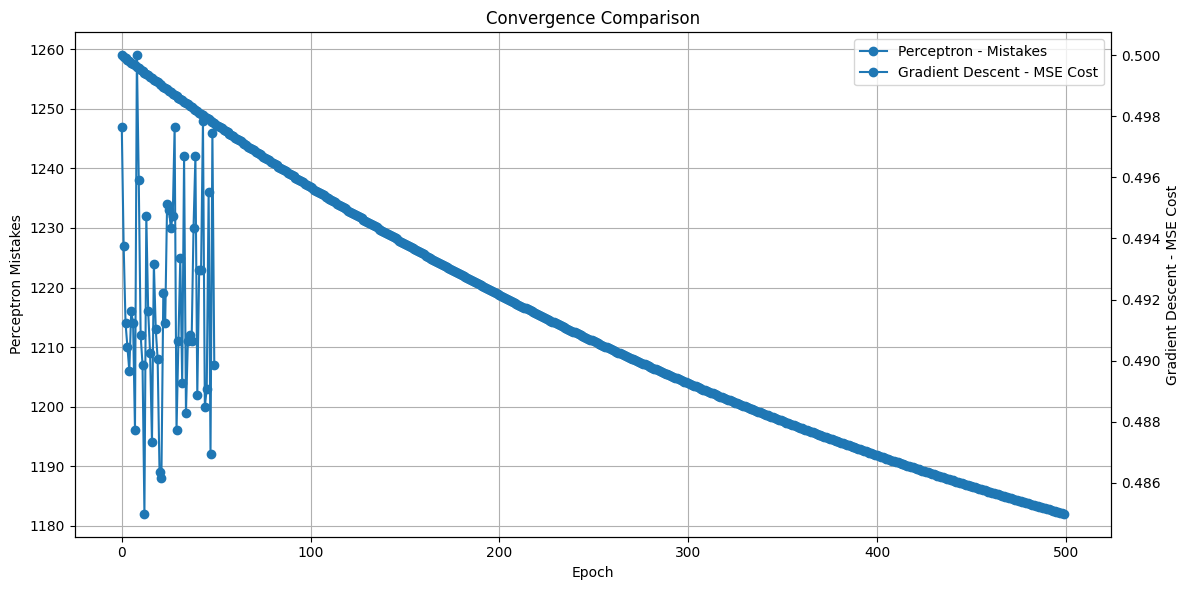

In [22]:


fig, ax1 = plt.subplots(figsize=(12, 6))

# Perceptron mistakes
ax1.plot(
    model_p.mistakes,
    label="Perceptron - Mistakes",
    marker="o"
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perceptron Mistakes")

# Gradient Descent cost
ax2 = ax1.twinx()
ax2.plot(
    model_gd.cost_history,
    label="Gradient Descent - MSE Cost",
    marker="o"
)
ax2.set_ylabel("Gradient Descent - MSE Cost")

plt.title("Convergence Comparison")

ax1.grid(True)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

**Accuracy Report:**
The test accuracy of the Perceptron, Gradient Descent, and Margin Classifier models was calculated using the test dataset. The model with the highest test accuracy performed best in terms of classification correctness. However, accuracy alone does not determine the safest model, especially when samples are close to the decision boundary. The Margin Classifier can provide better robustness because it explicitly considers the classification margin.


In [24]:
from sklearn.metrics import accuracy_score

# Phase 1: Perceptron
y_pred_p = model_p.predict(X_test)
accuracy_p = accuracy_score(y_test, y_pred_p)

# Phase 2: Gradient Descent
y_pred_gd = model_gd.predict(X_test)
accuracy_gd = accuracy_score(y_test, y_pred_gd)

# Phase 3: Margin Classifier
y_pred_margin = model_margin.predict(X_test)
accuracy_margin = accuracy_score(y_test, y_pred_margin)

print(f"Perceptron Accuracy: {accuracy_p * 100:.2f}%")
print(f"Gradient Descent Accuracy: {accuracy_gd * 100:.2f}%")
print(f"Margin Classifier Accuracy: {accuracy_margin * 100:.2f}%")

Perceptron Accuracy: 50.15%
Gradient Descent Accuracy: 62.80%
Margin Classifier Accuracy: 62.80%


compare them visually:

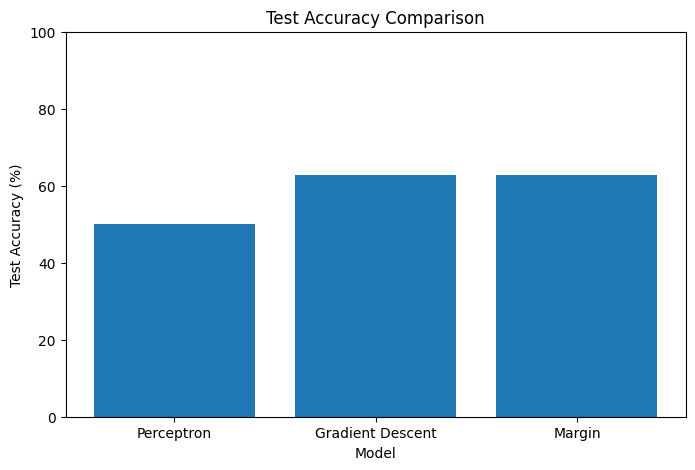

In [25]:
models = ["Perceptron", "Gradient Descent", "Margin"]
accuracies = [
    accuracy_p * 100,
    accuracy_gd * 100,
    accuracy_margin * 100
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

### 3. Safety Margin

If a **new water sample is very close to the decision boundary**, I would trust the **Margin Classifier** more than the basic Perceptron.

**Reason:** The Margin Classifier uses **Hinge Loss + L2 Regularization** and tries to create a safety gap between the two classes.

The Perceptron mainly focuses on whether a sample is **correctly or incorrectly classified**. It does not explicitly try to maximize the distance between the decision boundary and the samples.

The Margin Classifier, on the other hand, considers the margin condition:

[
y_i(w^T x_i+b) \geq 1
]

This encourages correctly classified samples to be **outside the margin**, rather than simply being on the correct side of the decision boundary.

### Final Comparison

| Model                 | Main Idea                      | Strength                     |
| --------------------- | ------------------------------ | ---------------------------- |
| **Perceptron**        | Correct classification         | Simple and fast              |
| **Gradient Descent**  | Minimize MSE                   | Smooth optimization          |
| **Margin Classifier** | Hinge Loss + L2 Regularization | Better separation and margin |

### Conclusion

For water-safety classification, the **Margin Classifier is preferable when samples are close to the decision boundary** because it explicitly considers a safety margin and is designed to provide more robust separation between safe and unsafe samples.


# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*




### Q1: Impact of High Learning Rate in Gradient Descent

If the **learning rate is set too high**, such as `1.0`, Gradient Descent may take very large steps while updating the weights and bias.

Instead of gradually moving toward the minimum of the loss function, the algorithm may **overshoot the minimum** repeatedly. This can cause the cost to oscillate or even increase instead of decreasing.

As a result, the model may **fail to converge or diverge**.

**In short:**
A very high learning rate can cause **overshooting → oscillation → divergence**, leading to poor model performance.

---

### Q2: Label Conversion in Classification

We converted the labels from **{0, 1} to {-1, +1}** because the Perceptron and Hinge Loss use the mathematical expression:

[
y_i(w^Tx_i+b)
]

where the label (y_i) is expected to be either **-1 or +1**.

For Hinge Loss:

[
L = \max(0, 1-y_i(w^Tx_i+b))
]

Using `-1` and `+1` makes the two classes **symmetric around zero**:

* Safe → `+1`
* Unsafe → `-1`

If we used `0` and `1`, a label of `0` would make the term (y_i(w^Tx_i+b)) equal to zero, which would not properly represent the negative class in the Perceptron or Hinge Loss formulation.

**In short:**
`{-1, +1}` labels make the mathematical formulation of **Perceptron and Hinge Loss** work correctly and symmetrically.

---

### Q3: Handling Noisy Data — Water Potability Dataset

Among the three algorithms implemented, the **Margin Classifier** is best suited for handling noisy data.

The Water Potability dataset may contain overlapping or incorrectly classified samples, meaning that the data is **not perfectly linearly separable**.

The Margin Classifier uses **Hinge Loss + L2 Regularization**. The margin encourages the model to find a robust decision boundary, while L2 regularization helps prevent excessively large weights and reduces overfitting.

The basic Perceptron can be sensitive to noisy or misclassified samples because it keeps updating whenever it encounters a mistake.

**Therefore, the Margin Classifier is the preferred choice for noisy water-potability data because it provides a more robust decision boundary and better generalization.**

### Summary

| Question                    | Answer                                                       |
| --------------------------- | ------------------------------------------------------------ |
| **Q1: High learning rate**  | Can cause overshooting, oscillation, and divergence          |
| **Q2: Why {-1, +1}?**       | Required for the symmetric Perceptron/Hinge Loss formulation |
| **Q3: Best for noisy data** | **Margin Classifier**, due to margin + L2 regularization     |
